# Stage 1 — Image-Derived Class Prototypes

This independent Colab notebook evaluates cosine-nearest class prototypes computed from frozen **ResNet-18** and **DINOv2 ViT-S/14** features on **DTD partition 1**, **FGVC-Aircraft (variant)**, and **Oxford Flowers-102**. It follows the required normalization order, official splits, three few-shot subset seeds, and one full-data run. No classifier or Flow Matching component is trained.

## 1. Install dependencies

In [1]:
%pip -q install scikit-learn pandas seaborn tqdm


In [2]:
%pip -q install open_clip_torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.7 MB/s eta 0:00:00


## 2. Mount Drive and configure artifact folders

In [3]:
from pathlib import Path
USE_DRIVE = True
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/Flow-Matching')
else:
    PROJECT_ROOT = Path('/content/Flow-Matching')
DATA_ROOT = PROJECT_ROOT / 'data'
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'image_prototypes'
CACHE_ROOT = PROJECT_ROOT / 'feature_cache'
for p in [DATA_ROOT, OUTPUT_ROOT, CACHE_ROOT]: p.mkdir(parents=True, exist_ok=True)
print('Project root:', PROJECT_ROOT)


Mounted at /content/drive
Project root: /content/drive/MyDrive/Flow-Matching


## 3. Imports, GPU detection, and protocol configuration
The same dataset, feature-cache, seed, and plotting conventions are used as in the linear-probe notebook.

In [4]:
import json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.models import ResNet18_Weights
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from tqdm.auto import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PIN_MEMORY = DEVICE.type == 'cuda'
print('Device:', DEVICE, '| GPU:', torch.cuda.get_device_name(0) if PIN_MEMORY else 'none')
DATASETS = ['dtd', 'aircraft', 'flowers102']
ENCODERS = ['resnet18', 'dinov2_vits14']
SHOT_SETTINGS = [5, 10, 'full']
SUBSET_SEEDS = [0, 1, 2]
BATCH_SIZE_IMAGES = 128
NUM_WORKERS = 2
random.seed(0); np.random.seed(0); torch.manual_seed(0)
CONFIG = dict(datasets=DATASETS, encoders=ENCODERS, shots=SHOT_SETTINGS, subset_seeds=SUBSET_SEEDS, method='normalize features -> class mean -> normalize prototype')
(OUTPUT_ROOT / 'config.json').write_text(json.dumps(CONFIG, indent=2))


Device: cuda | GPU: Tesla T4


284

## 4. Official datasets and checkpoint preprocessing

In [5]:
def build_dataset(name, split, transform):
    if name == 'dtd': return datasets.DTD(DATA_ROOT, split=split, partition=1, transform=transform, download=True)
    if name == 'aircraft': return datasets.FGVCAircraft(DATA_ROOT, split=split, annotation_level='variant', transform=transform, download=True)
    if name == 'flowers102': return datasets.Flowers102(DATA_ROOT, split=split, transform=transform, download=True)
    raise ValueError(name)

def targets_of(ds):
    for attr in ('_labels', 'targets', 'labels'):
        if hasattr(ds, attr): return np.asarray(getattr(ds, attr), dtype=int)
    return np.asarray([ds[i][1] for i in range(len(ds))], dtype=int)

def class_names_of(ds):
    if hasattr(ds, 'classes'): return [str(x).replace('_', ' ') for x in ds.classes]
    return [f'class {i + 1}' for i in range(int(targets_of(ds).max()) + 1)]

def load_encoder(name):
    if name == 'resnet18':
        weights = ResNet18_Weights.IMAGENET1K_V1; net = models.resnet18(weights=weights); net.fc = nn.Identity(); preprocess = weights.transforms()
    elif name == 'dinov2_vits14':
        net = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
        preprocess = transforms.Compose([transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC), transforms.CenterCrop(224), transforms.ToTensor(), transforms.Normalize((0.485,0.456,0.406),(0.229,0.224,0.225))])
    else: raise ValueError(name)
    net.eval().to(DEVICE)
    for p in net.parameters(): p.requires_grad_(False)
    assert not any(p.requires_grad for p in net.parameters())
    return net, preprocess

@torch.inference_mode()
def extract_split(dataset_name, split, encoder_name, encoder, preprocess):
    cache = CACHE_ROOT / f'{dataset_name}__{encoder_name}__{split}.pt'
    if cache.exists(): return torch.load(cache, map_location='cpu', weights_only=False)
    ds = build_dataset(dataset_name, split, preprocess); loader = DataLoader(ds, batch_size=BATCH_SIZE_IMAGES, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    zs, ys = [], []
    for images, labels in tqdm(loader, desc=f'{dataset_name}/{encoder_name}/{split}'):
        zs.append(encoder(images.to(DEVICE, non_blocking=True)).float().cpu()); ys.append(labels.long())
    item = dict(features=torch.cat(zs), labels=torch.cat(ys), classes=class_names_of(ds), dataset=dataset_name, split=split, encoder=encoder_name)
    assert len(item['features']) == len(ds) and torch.isfinite(item['features']).all()
    torch.save(item, cache); return item


### Comprehensive matrix configuration
The image-prototype baseline uses both ResNet-18 and DINOv2 on DTD, FGVC-Aircraft, and Flowers-102. CLIP RN50 remains in the separate zero-shot text-prototype notebook, matching the method defined in the specification.

In [6]:
import copy, time
DEFAULT_STAGE1 = {
    'config_revision': 3,
    'plan': {
        'datasets': ['dtd', 'aircraft', 'flowers102'],
        'encoders_by_dataset': {d: ['resnet18', 'dinov2_vits14'] for d in ['dtd', 'aircraft', 'flowers102']},
        'prototype_branch': 'all', 'prototype_branches': ['image', 'zero_shot_clip'],
        'shots': [5, 10, 'full'], 'subset_seeds': [0, 1, 2], 'init_seeds': [0, 1, 2]
    },
    'feature_cache': {'schema_version': 2, 'batch_size': 64, 'num_workers': 0},
    'linear_probe': {'batch_size': 64, 'max_epochs': 200, 'early_stopping_patience': 25, 'lr_patience': 10, 'min_delta': 1e-4, 'checkpoint_interval': 10, 'resume_training': True, 'candidates': []}
}
config_paths = [PROJECT_ROOT / 'stage1_config.json', Path.cwd() / 'stage1_config.json', Path('/content/stage1_config.json')]
config_path = next((p for p in config_paths if p.exists()), PROJECT_ROOT / 'stage1_config.json')
if config_path.exists():
    with config_path.open() as f: STAGE1 = json.load(f)
else:
    STAGE1 = copy.deepcopy(DEFAULT_STAGE1)
if STAGE1.get('config_revision', 0) < 3:
    STAGE1['plan'] = copy.deepcopy(DEFAULT_STAGE1['plan']); STAGE1['feature_cache'].update(DEFAULT_STAGE1['feature_cache']); STAGE1['config_revision'] = 3
config_path.parent.mkdir(parents=True, exist_ok=True); config_path.write_text(json.dumps(STAGE1, indent=2))
print('Loaded configuration from:', config_path)
PLAN = STAGE1['plan']
assert 'image' in PLAN.get('prototype_branches', [PLAN.get('prototype_branch')]), 'Image prototypes are not enabled.'
DATASETS = PLAN['datasets']; ENCODERS_BY_DATASET = PLAN['encoders_by_dataset']
ENABLED_PAIRS = [(d, e) for d in DATASETS for e in ENCODERS_BY_DATASET[d]]
ENCODERS = list(dict.fromkeys(e for _, e in ENABLED_PAIRS))
SHOT_SETTINGS = PLAN['shots']; SUBSET_SEEDS = PLAN['subset_seeds']
BATCH_SIZE_IMAGES = STAGE1['feature_cache']['batch_size']; NUM_WORKERS = STAGE1['feature_cache']['num_workers']
CACHE_ROOT = PROJECT_ROOT / 'feature_cache' / f"v{STAGE1['feature_cache']['schema_version']}"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
CONFIG = dict(STAGE1, enabled_pairs=ENABLED_PAIRS, method='normalize features -> class mean -> normalize prototype')
_ = (OUTPUT_ROOT / 'config.json').write_text(json.dumps(CONFIG, indent=2))


Loaded configuration from: /content/drive/MyDrive/Flow-Matching/stage1_config.json


In [7]:
if Path('/content').exists():
    DATA_ROOT = Path('/content/flow_matching_data')
    DATA_ROOT.mkdir(parents=True, exist_ok=True)
    NUM_WORKERS = 0
    BATCH_SIZE_IMAGES = min(BATCH_SIZE_IMAGES, 32)
print('Dataset root:', DATA_ROOT, '| workers:', NUM_WORKERS, '| batch:', BATCH_SIZE_IMAGES)


Dataset root: /content/flow_matching_data | workers: 0 | batch: 32


## 5. Cache frozen train/validation/test representations

In [8]:
feature_bank = {}
for encoder_name in ENCODERS:
    encoder, preprocess = load_encoder(encoder_name)
    for dataset_name, enabled_encoder in ENABLED_PAIRS:
        if enabled_encoder != encoder_name: continue
        feature_bank[(dataset_name, encoder_name)] = {split: extract_split(dataset_name, split, encoder_name, encoder, preprocess) for split in ('train','val','test')}
    del encoder
    if torch.cuda.is_available(): torch.cuda.empty_cache()
print('Cached combinations:', list(feature_bank))


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 235MB/s]


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 300MB/s]


Cached combinations: [('dtd', 'resnet18'), ('aircraft', 'resnet18'), ('flowers102', 'resnet18'), ('dtd', 'dinov2_vits14'), ('aircraft', 'dinov2_vits14'), ('flowers102', 'dinov2_vits14')]


## 6. Balanced subsets, normalized prototypes, and cosine evaluation
The exact required operation is `normalize(each z_i)`, average within class, then `normalize(class mean)`. Validation accuracy is recorded for diagnostics; final reporting uses the complete official test split.

In [9]:
def balanced_indices(labels, k, seed):
    labels = np.asarray(labels); rng = np.random.default_rng(seed); chosen = []
    for c in np.unique(labels):
        idx = np.flatnonzero(labels == c)
        if len(idx) < k: raise ValueError(f'class {c} has fewer than {k} training examples')
        chosen.extend(rng.choice(idx, k, replace=False).tolist())
    return np.asarray(sorted(chosen))

def make_prototypes(features, labels, n_classes):
    features = F.normalize(features.float(), dim=1)
    prototypes = torch.stack([features[labels == c].mean(0) for c in range(n_classes)])
    assert torch.isfinite(prototypes).all()
    return F.normalize(prototypes, dim=1)

@torch.inference_mode()
def predict_cosine(features, prototypes):
    scores = F.normalize(features.float(), dim=1) @ prototypes.T
    return scores.argmax(1), scores

def evaluate_setting(bank, dataset_name, encoder_name, shot, seed):
    x_train, y_train = bank['train']['features'], bank['train']['labels']
    if shot != 'full':
        idx = torch.as_tensor(balanced_indices(y_train.numpy(), int(shot), seed)); x_train, y_train = x_train[idx], y_train[idx]
    prototypes = make_prototypes(x_train, y_train, len(bank['train']['classes']))
    val_pred, _ = predict_cosine(bank['val']['features'], prototypes); test_pred, scores = predict_cosine(bank['test']['features'], prototypes)
    val_acc = (val_pred == bank['val']['labels']).float().mean().item(); test_acc = (test_pred == bank['test']['labels']).float().mean().item()
    run_dir = OUTPUT_ROOT / 'runs' / dataset_name / encoder_name / str(shot) / f'seed_{seed}'; run_dir.mkdir(parents=True, exist_ok=True)
    torch.save(dict(prototypes=prototypes, classes=bank['train']['classes'], shot=str(shot), seed=seed), run_dir / 'prototypes.pt')
    np.save(run_dir / 'test_predictions.npy', test_pred.numpy()); np.save(run_dir / 'test_cosine_scores.npy', scores.numpy())
    metrics = dict(dataset=dataset_name, encoder=encoder_name, shot=str(shot), seed=seed, validation_accuracy=val_acc, test_accuracy=test_acc)
    (run_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2))
    return metrics, prototypes, test_pred


### Reproducibility artifacts and resource tracking
Image prototypes are closed-form: there are no epochs or optimizer state to resume. Each run instead saves identical `best.pt` and `final.pt` prototype artifacts with configuration metadata, plus runtime and peak GPU-memory metrics.

In [10]:
_base_evaluate_setting = evaluate_setting
def evaluate_setting(bank, dataset_name, encoder_name, shot, seed):
    if DEVICE.type == 'cuda': torch.cuda.reset_peak_memory_stats()
    started = time.perf_counter()
    metrics, prototypes, test_pred = _base_evaluate_setting(bank, dataset_name, encoder_name, shot, seed)
    metrics['runtime_seconds'] = time.perf_counter() - started
    metrics['peak_gpu_memory_mb'] = torch.cuda.max_memory_allocated() / 2**20 if DEVICE.type == 'cuda' else 0.0
    run_dir = OUTPUT_ROOT / 'runs' / dataset_name / encoder_name / str(shot) / f'seed_{seed}'
    checkpoint_dir = run_dir / 'checkpoints'; checkpoint_dir.mkdir(parents=True, exist_ok=True)
    artifact = dict(prototypes=prototypes, classes=bank['train']['classes'], shot=str(shot), seed=seed, config=CONFIG, epoch=None, optimizer_state_dict=None, metrics=metrics, note='Closed-form method: optimizer, epochs, resume, and intermediate training checkpoints are not applicable.')
    torch.save(artifact, checkpoint_dir / 'best.pt'); torch.save(artifact, checkpoint_dir / 'final.pt')
    (run_dir / 'metrics.json').write_text(json.dumps(metrics, indent=2))
    return metrics, prototypes, test_pred


## 7. Run all datasets, encoders, and training sizes
5-shot and 10-shot use subset seeds 0, 1, and 2. Full data requires one run, represented by seed 0.

In [11]:
rows, prototype_bank, prediction_bank = [], {}, {}
for dataset_name, encoder_name in ENABLED_PAIRS:
    bank = feature_bank[(dataset_name, encoder_name)]
    for shot in SHOT_SETTINGS:
        seeds = SUBSET_SEEDS if shot != 'full' else [0]
        for seed in seeds:
            metrics, prototypes, pred = evaluate_setting(bank, dataset_name, encoder_name, shot, seed)
            rows.append(metrics); prototype_bank[(dataset_name,encoder_name,str(shot),seed)] = prototypes; prediction_bank[(dataset_name,encoder_name,str(shot),seed)] = pred
results_df = pd.DataFrame(rows); results_df.to_csv(OUTPUT_ROOT / 'run_metrics.csv', index=False); display(results_df)


,dataset,encoder,shot,seed,validation_accuracy,test_accuracy,runtime_seconds,peak_gpu_memory_mb
0,dtd,resnet18,5,0,0.461702,0.472340,0.134774,0.0
1,dtd,resnet18,5,1,0.461702,0.462766,0.039777,0.0
2,dtd,resnet18,5,2,0.434574,0.460106,0.039891,0.0
3,dtd,resnet18,10,0,0.501064,0.523936,0.043844,0.0
4,dtd,resnet18,10,1,0.527128,0.544681,0.053695,0.0
5,dtd,resnet18,10,2,0.506383,0.532447,0.039086,0.0
6,dtd,resnet18,full,0,0.553723,0.587766,0.040564,0.0
7,dtd,dinov2_vits14,5,0,0.632979,0.645745,0.043863,0.0
8,dtd,dinov2_vits14,5,1,0.637234,0.645213,0.036545,0.0
9,dtd,dinov2_vits14,5,2,0.630851,0.636702,0.050452,0.0


## 8. Accuracy table and training-size curves

,dataset,encoder,shot,mean_accuracy,std_accuracy,runs
0,aircraft,dinov2_vits14,10,0.2781,0.0127,3
1,aircraft,dinov2_vits14,5,0.2326,0.0127,3
2,aircraft,dinov2_vits14,full,0.3423,nan,1
3,aircraft,resnet18,10,0.1985,0.0047,3
4,aircraft,resnet18,5,0.1604,0.0083,3
5,aircraft,resnet18,full,0.2520,nan,1
6,dtd,dinov2_vits14,10,0.6938,0.0019,3
7,dtd,dinov2_vits14,5,0.6426,0.0051,3
8,dtd,dinov2_vits14,full,0.7266,nan,1
9,dtd,resnet18,10,0.5337,0.0104,3


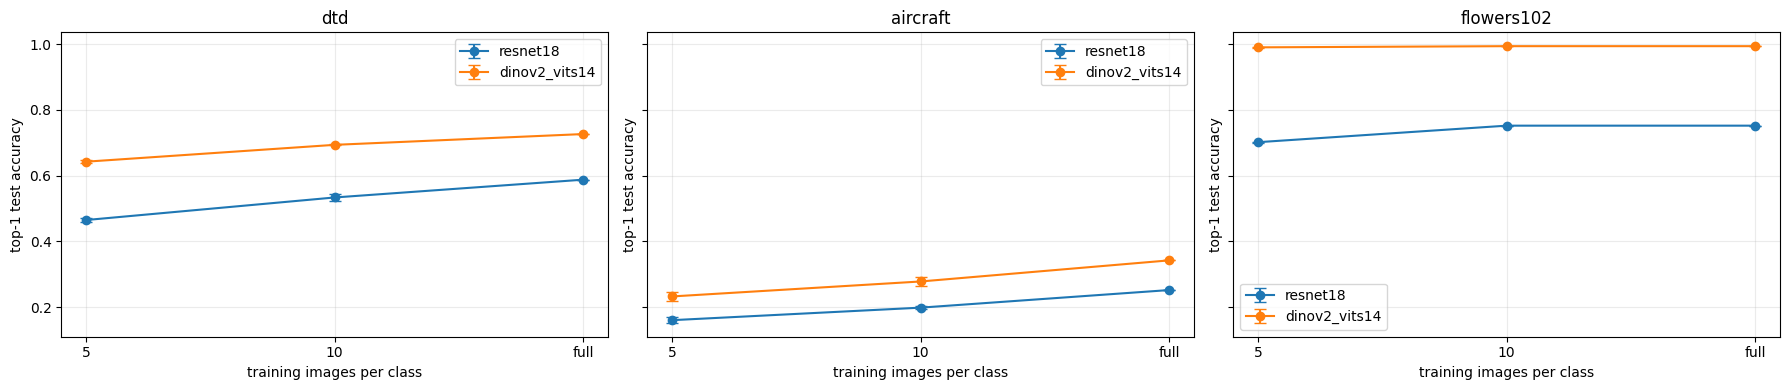

In [12]:
summary = results_df.groupby(['dataset','encoder','shot'], as_index=False).agg(mean_accuracy=('test_accuracy','mean'), std_accuracy=('test_accuracy','std'), runs=('test_accuracy','size'))
summary.to_csv(OUTPUT_ROOT / 'accuracy_summary.csv', index=False); display(summary.style.format({'mean_accuracy':'{:.4f}','std_accuracy':'{:.4f}'}))
fig, axes = plt.subplots(1, len(DATASETS), figsize=(6*len(DATASETS),4), sharey=True, squeeze=False); axes=axes.ravel()
for ax, dataset_name in zip(axes, DATASETS):
    part = summary[summary.dataset == dataset_name].copy(); part['x'] = part.shot.map({'5':0,'10':1,'full':2})
    for encoder_name in ENCODERS_BY_DATASET[dataset_name]:
        row = part[part.encoder == encoder_name].sort_values('x'); ax.errorbar(row.x,row.mean_accuracy,yerr=row.std_accuracy.fillna(0),marker='o',capsize=4,label=encoder_name)
    ax.set(title=dataset_name,xticks=[0,1,2],xticklabels=['5','10','full'],xlabel='training images per class',ylabel='top-1 test accuracy'); ax.grid(alpha=.25); ax.legend()
fig.tight_layout(); fig.savefig(OUTPUT_ROOT/'accuracy_vs_training_size.png',dpi=180,bbox_inches='tight'); plt.show()


## 9. Representative row-normalized confusion matrices
DINOv2 10-shot seed 0 is used consistently.

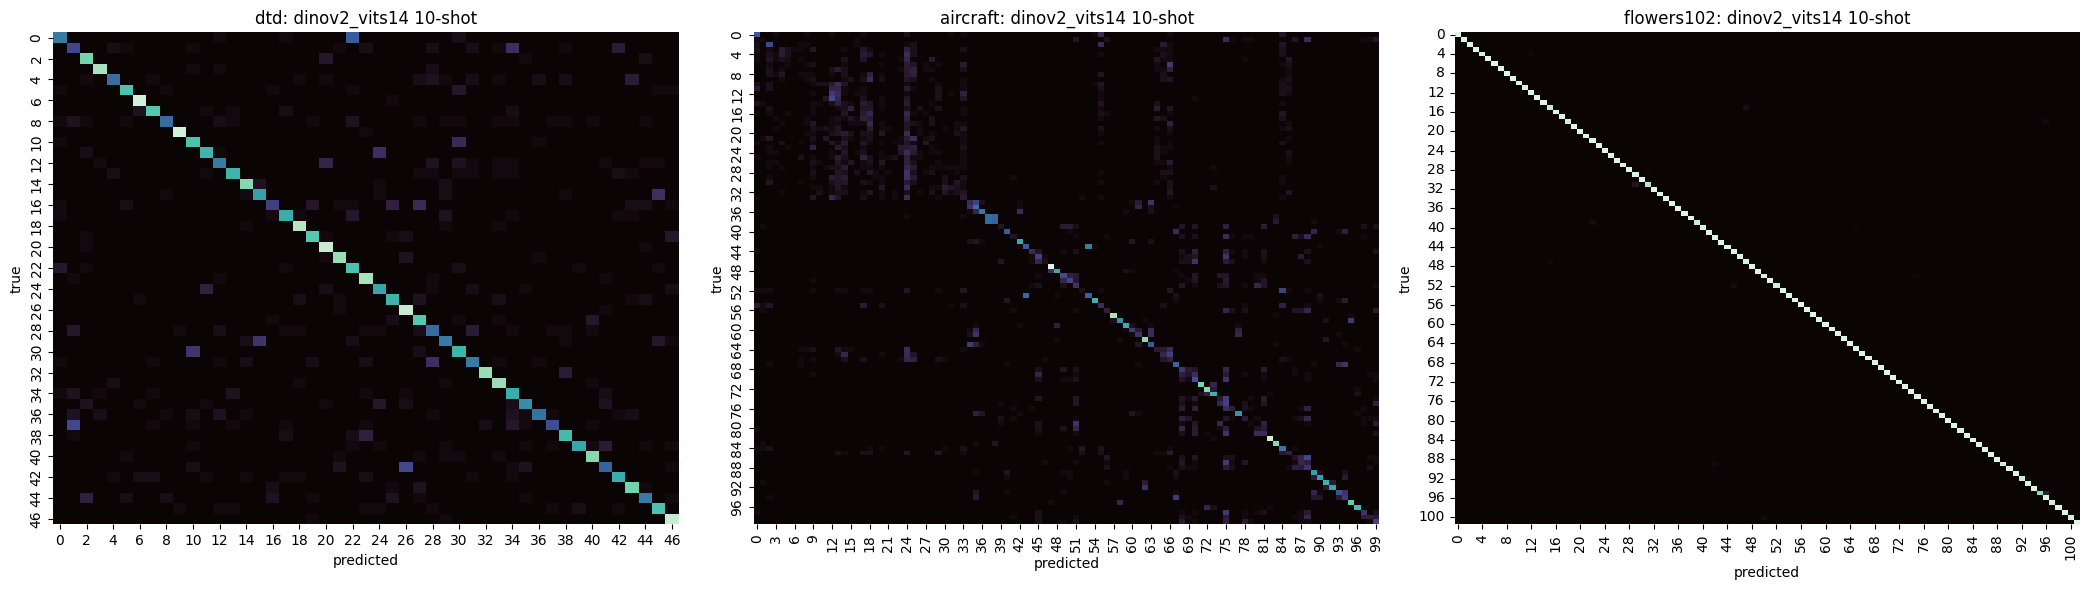

In [13]:
fig, axes = plt.subplots(1,len(DATASETS),figsize=(7*len(DATASETS),6),squeeze=False); axes=axes.ravel()
for ax,dataset_name in zip(axes,DATASETS):
    encoder_name=ENCODERS_BY_DATASET[dataset_name][-1]; bank=feature_bank[(dataset_name,encoder_name)]; y=bank['test']['labels'].numpy(); pred=prediction_bank[(dataset_name,encoder_name,'10',0)].numpy()
    sns.heatmap(confusion_matrix(y,pred,normalize='true'),cmap='mako',vmin=0,vmax=1,cbar=False,ax=ax); ax.set(title=f'{dataset_name}: {encoder_name} 10-shot',xlabel='predicted',ylabel='true')
fig.tight_layout(); fig.savefig(OUTPUT_ROOT/'confusion_matrices.png',dpi=180,bbox_inches='tight'); plt.show()


## 10. Joint PCA of test features and prototypes
For each plot, PCA is fitted jointly to the displayed test features and prototypes, as required. The same first 10 classes and deterministic test examples are used for comparable encoder plots.

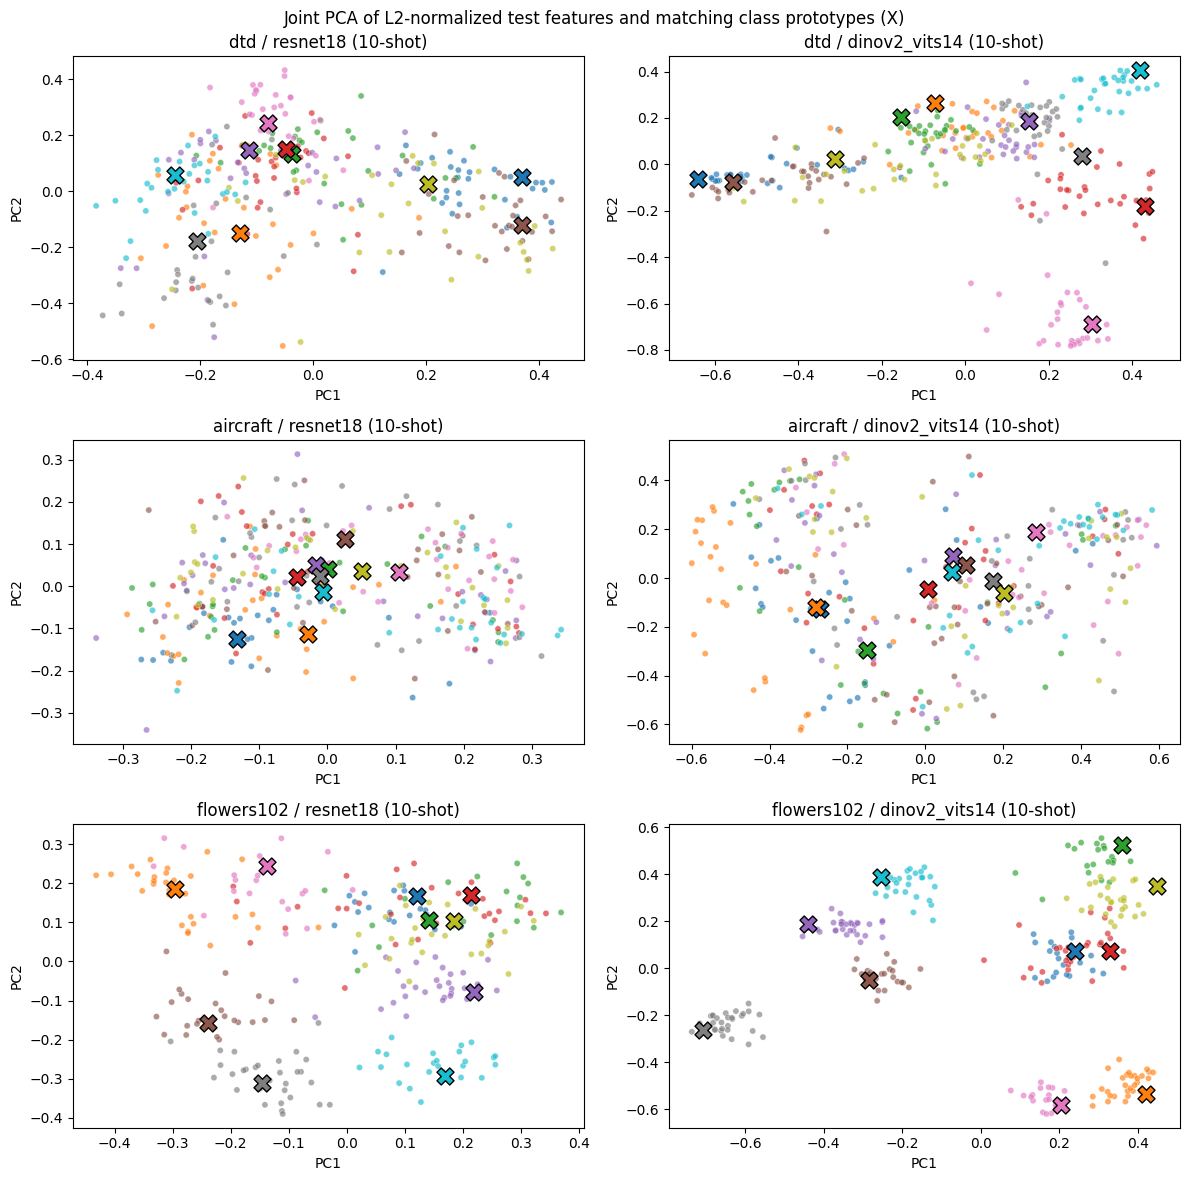

Artifacts saved to: /content/drive/MyDrive/Flow-Matching/outputs/image_prototypes


In [14]:
max_encoders=max(len(v) for v in ENCODERS_BY_DATASET.values()); fig,axes=plt.subplots(len(DATASETS),max_encoders,figsize=(6*max_encoders,4*len(DATASETS)),squeeze=False)
for i,dataset_name in enumerate(DATASETS):
    selected_classes=np.arange(10); base_y=feature_bank[(dataset_name,'resnet18')]['test']['labels'].numpy(); selected_idx=np.concatenate([np.flatnonzero(base_y==c)[:30] for c in selected_classes])
    for j,encoder_name in enumerate(ENCODERS_BY_DATASET[dataset_name]):
        bank=feature_bank[(dataset_name,encoder_name)]['test']; z=F.normalize(bank['features'][selected_idx].float(),dim=1); y=bank['labels'][selected_idx].numpy(); prot=prototype_bank[(dataset_name,encoder_name,'10',0)][selected_classes]
        joint=torch.cat([z,prot]).numpy(); xy=PCA(n_components=2).fit_transform(joint); n=len(z)
        palette=sns.color_palette('tab10',10); sns.scatterplot(x=xy[:n,0],y=xy[:n,1],hue=y,palette=palette,s=20,alpha=.65,ax=axes[i,j],legend=False)
        for k,c in enumerate(selected_classes): axes[i,j].scatter(xy[n+k,0],xy[n+k,1],color=palette[k],marker='X',s=150,edgecolors='black')
        axes[i,j].set(title=f'{dataset_name} / {encoder_name} (10-shot)',xlabel='PC1',ylabel='PC2')
    for j in range(len(ENCODERS_BY_DATASET[dataset_name]),max_encoders): axes[i,j].axis('off')
fig.suptitle('Joint PCA of L2-normalized test features and matching class prototypes (X)'); fig.tight_layout(); fig.savefig(OUTPUT_ROOT/'joint_feature_prototype_pca.png',dpi=180,bbox_inches='tight'); plt.show()
print('Artifacts saved to:',OUTPUT_ROOT)


## 12. Encoder comparison table
Every encoder has separate prototype artifacts, metrics, runtime, and peak-memory records.

In [15]:
encoder_comparison=results_df.groupby(['dataset','encoder'],as_index=False).agg(mean_test_accuracy=('test_accuracy','mean'),std_test_accuracy=('test_accuracy','std'),mean_runtime_seconds=('runtime_seconds','mean'),max_peak_gpu_memory_mb=('peak_gpu_memory_mb','max'),total_runs=('test_accuracy','size'))
encoder_comparison.to_csv(OUTPUT_ROOT/'encoder_comparison.csv',index=False); display(encoder_comparison.style.format({'mean_test_accuracy':'{:.4f}','std_test_accuracy':'{:.4f}','mean_runtime_seconds':'{:.3f}','max_peak_gpu_memory_mb':'{:.1f}'}))


,dataset,encoder,mean_test_accuracy,std_test_accuracy,mean_runtime_seconds,max_peak_gpu_memory_mb,total_runs
0,aircraft,dinov2_vits14,0.2678,0.0413,0.058,0.0,7
1,aircraft,resnet18,0.1898,0.0338,0.068,0.0,7
2,dtd,dinov2_vits14,0.6765,0.0340,0.040,0.0,7
3,dtd,resnet18,0.5120,0.0484,0.056,0.0,7
4,flowers102,dinov2_vits14,0.9924,0.0021,0.091,0.0,7
5,flowers102,resnet18,0.7306,0.0269,0.065,0.0,7
